In [64]:
from Autograder_Util import parse_medians

ref_file = "graphics.txt"
ref_data, char_list = parse_medians(ref_file)
print(len(char_list))
# print(char_list)

9574


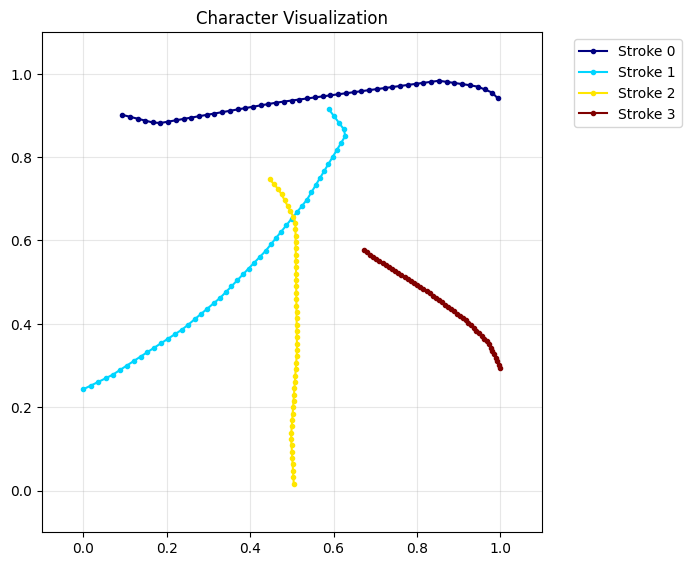

In [65]:
from Autograder_Util import preprocess_characters
from Autograder_Util import plot_character
from Autograder_Util import load_dictionary_characters

normalized_reference_data = preprocess_characters(ref_data, flip_y = False) #dict of char keys, value is list of strokes
plot_character(normalized_reference_data['不'])


In [66]:
from Autograder_Util import load_dictionary_characters

char_dict = load_dictionary_characters('dictionary.txt') #dict of chars, value is dict of high-level data.
print(char_dict['你'])

{'character': '你', 'definition': 'you, second person pronoun', 'pinyin': ['nǐ'], 'decomposition': '⿰亻尔', 'etymology': {'type': 'ideographic', 'hint': 'Pronoun\xa0尔 for a person\xa0亻'}, 'radical': '亻', 'matches': [[0], [0], [1], [1], [1], [1], [1]]}


In [67]:
#Complicated function but it contains methods for recursively removing radicals from a char

import random

IDC = set('⿰⿱⿲⿳⿴⿵⿶⿷⿸⿹⿺⿻')


def decompose(char, char_db, visited=None):
    """
    Returns a decomposition tree:
    {
        'char': str,
        'idc': str | None,
        'components': [...]
    }
    """

    if visited is None:
        visited = set()

    entry = char_db.get(char)

    if not entry:
        return {'char': char, 'idc': None, 'components': []}

    decomp = entry.get('decomposition', '？')
    strokes = len(entry.get('matches', []))

    if char in visited or decomp == '？' or strokes <= 3:
        return {'char': char, 'idc': None, 'components': []}

    idc = decomp[0] if decomp[0] in IDC else None
    components = [c for c in decomp if c not in IDC and c != '？']

    return {
        'char': char,
        'idc': idc,
        'components': [
            decompose(c, char_db, visited | {char})
            for c in components
        ]
    }


def get_leaves(node):
    """Return primitive radicals."""

    if not node['components']:
        return [node['char']]

    leaves = []
    for c in node['components']:
        leaves.extend(get_leaves(c))

    return leaves


def subtree_contains(node, targets):
    """Check if a subtree contains a radical slated for removal."""

    if not node['components']:
        return node['char'] in targets

    return any(subtree_contains(c, targets) for c in node['components'])


def remove_radicals_stochastic(char, strokes, p_remove, char_db):
    entry = char_db.get(char)
    if not entry:
        return strokes
    matches = entry.get("matches", [])
    decomp = entry.get("decomposition", "？")
    components = [c for c in decomp if c not in IDC and c != "？"]

    if not components:
        if random.random() < p_remove:
            return []
        return strokes

    component_strokes = {i: [] for i in range(len(components))}
    unmatched = []
    for i, stroke in enumerate(strokes):
        match = matches[i] if i < len(matches) else None
        if match is None or not match:
            unmatched.append(stroke)
            continue
        component_idx = match[0]
        if component_idx < len(components):
            component_strokes[component_idx].append(stroke)
        else:
            unmatched.append(stroke)

    decisions = {}
    for i, comp_char in enumerate(components):
        comp_entry = char_db.get(comp_char)
        comp_stroke_count = len(comp_entry.get('matches', [])) if comp_entry else 0
        decisions[i] = ('primitive' if comp_stroke_count <= 3 else 'recurse', comp_char)

    drop = {i for i in decisions if random.random() < p_remove}
    if drop == set(decisions.keys()):
        drop.remove(random.choice(list(drop)))

    kept = list(unmatched)
    for i, (mode, comp_char) in decisions.items():
        comp_strokes = component_strokes[i]
        if not comp_strokes:
            continue
        if i in drop:
            continue  # drop this component entirely
        if mode == 'recurse':
            kept.extend(remove_radicals_stochastic(comp_char, comp_strokes, p_remove, char_db))
        else:
            kept.extend(comp_strokes)
    if not kept:
        fallback_idx = random.choice([i for i in decisions if i not in drop or component_strokes[i]])
        kept.extend(component_strokes[fallback_idx])

    return kept

result = remove_radicals_stochastic("我", normalized_reference_data['我'], 0.2, char_dict)

#next steps: tune the data generation removal algorithm likelihood so that it better reflects the probability true mistakes

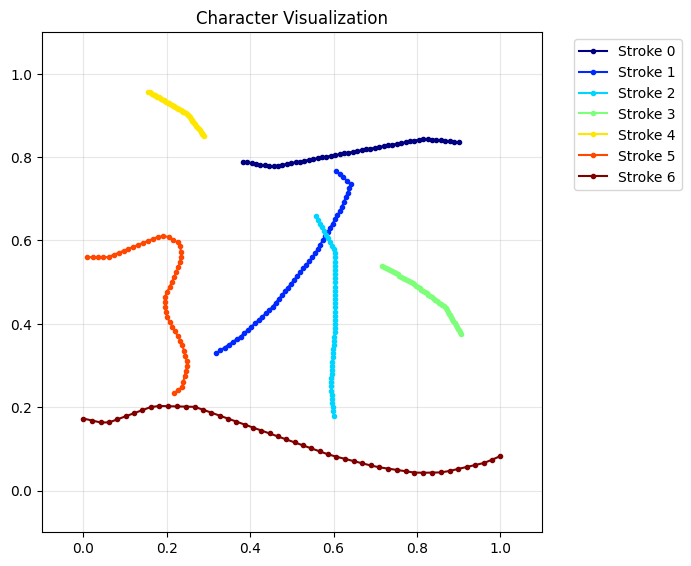

In [68]:
def remove_strokes_stochastic(strokes, p_remove):
    kept = [stroke for stroke in strokes if random.random() > p_remove]
    return kept if kept else [random.choice(strokes)]

result = remove_strokes_stochastic(normalized_reference_data['还'], 0.05)
plot_character(result)

#next steps: each char has a probability of each stroke being removed. Some strokes may be more commonly removed than others

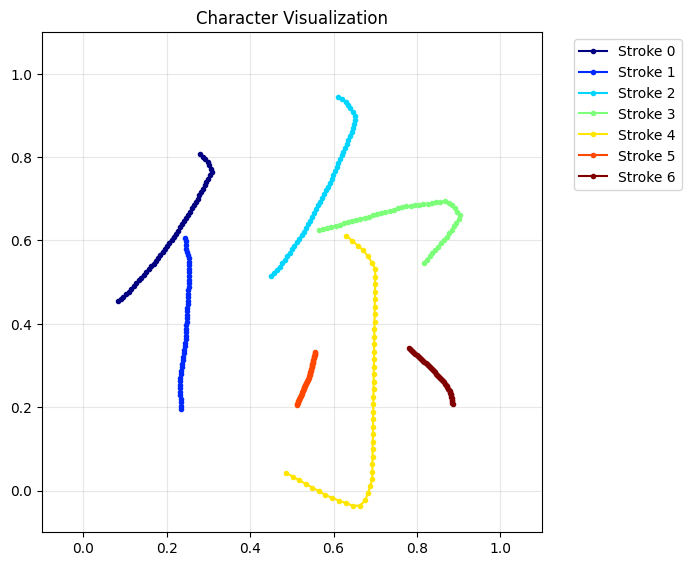

In [69]:
import numpy as np 

def scale_radicals_stochastic(char, strokes, std, char_db, _inherited_scale=1.0, _inherited_centroid=None, _depth=0):
    indent = "  " * _depth

    entry = char_db.get(char)
    components = []
    if entry:
        decomp = entry.get("decomposition", "？")
        components = [c for c in decomp if c not in IDC and c != "？"]

    if not entry or not components:
        centroid = np.vstack(strokes).mean(axis=0)
        scale = np.random.normal(1, std)
        scaled = [(s - centroid) * scale + centroid for s in strokes]
        return scaled

    matches = entry.get("matches", [])
    component_strokes = {i: [] for i in range(len(components))}
    unmatched = []
    for i, stroke in enumerate(strokes):
        match = matches[i] if i < len(matches) else None
        if match is None or not match:
            unmatched.append((i, stroke))
            continue
        component_idx = match[0]
        if component_idx < len(components):
            component_strokes[component_idx].append((i, stroke))
        else:
            unmatched.append((i, stroke))

    result = [None] * len(strokes)

    for i, indexed_strokes in component_strokes.items():
        if not indexed_strokes:
            continue
        idxs, comp_strokes = zip(*indexed_strokes)

        centroid = np.vstack(comp_strokes).mean(axis=0)
        local_scale = np.random.normal(1, std)
        cumulative_scale = _inherited_scale * local_scale

        locally_scaled = [(s - centroid) * local_scale + centroid for s in comp_strokes]

        recursed = scale_radicals_stochastic(
            components[i], locally_scaled, std, char_db,
            _inherited_scale=cumulative_scale,
            _inherited_centroid=centroid,
            _depth=_depth + 1
        )

        for idx, s in zip(idxs, recursed):
            result[idx] = s

    if unmatched:
        idxs, unmatched_strokes = zip(*unmatched)
        centroid = np.vstack(unmatched_strokes).mean(axis=0)
        scale = np.random.normal(1, std)
        for idx, stroke in zip(idxs, unmatched_strokes):
            result[idx] = (stroke - centroid) * scale + centroid

    return result

result = scale_radicals_stochastic('你', normalized_reference_data['你'], 0.2, char_dict)
plot_character(result)

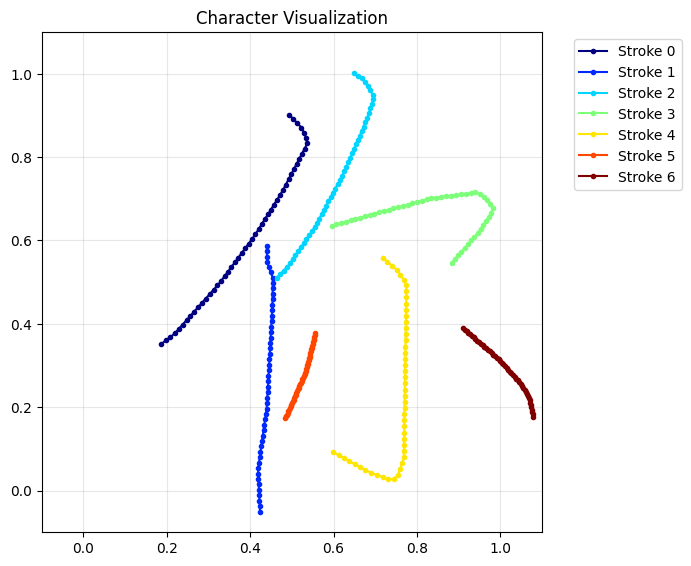

In [70]:
def shift_radicals_stochastic(char, strokes, std, char_db, _depth=0):
    indent = "  " * _depth

    entry = char_db.get(char)
    components = []
    if entry:
        decomp = entry.get("decomposition", "？")
        components = [c for c in decomp if c not in IDC and c != "？"]

    # leaf radical — shift all strokes together
    if not entry or not components:
        shift = np.random.normal(0, std, size=2)
        shifted = [s + shift for s in strokes]
        return shifted

    matches = entry.get("matches", [])
    component_strokes = {i: [] for i in range(len(components))}
    unmatched = []
    for i, stroke in enumerate(strokes):
        match = matches[i] if i < len(matches) else None
        if match is None or not match:
            unmatched.append((i, stroke))
            continue
        component_idx = match[0]
        if component_idx < len(components):
            component_strokes[component_idx].append((i, stroke))
        else:
            unmatched.append((i, stroke))

    result = [None] * len(strokes)

    for i, indexed_strokes in component_strokes.items():
        if not indexed_strokes:
            continue
        idxs, comp_strokes = zip(*indexed_strokes)

        # shift this component
        shift = np.random.normal(0, std, size=2)
        shifted = [s + shift for s in comp_strokes]

        # treat as leaf if 3 strokes or fewer
        if len(comp_strokes) <= 3:
            for idx, s in zip(idxs, shifted):
                result[idx] = s
        else:
            recursed = shift_radicals_stochastic(
                components[i], shifted, std, char_db,
                _depth=_depth + 1
            )
            for idx, s in zip(idxs, recursed):
                result[idx] = s

    # unmatched strokes shifted together as a group
    if unmatched:
        idxs, unmatched_strokes = zip(*unmatched)
        shift = np.random.normal(0, std, size=2)
        for idx, stroke in zip(idxs, unmatched_strokes):
            result[idx] = stroke + shift

    return result


result = shift_radicals_stochastic('你', normalized_reference_data['你'], 0.07, char_dict)
plot_character(result)


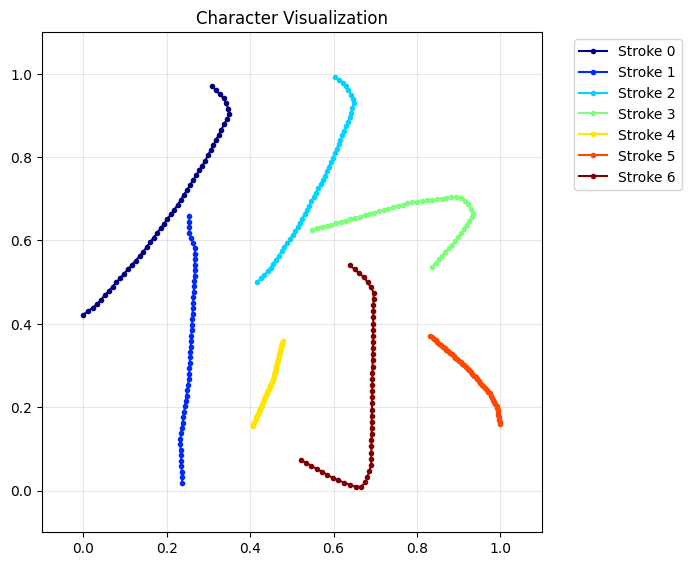

In [71]:
def shuffle_strokes_stochastic(char, strokes, p_shuffle, char_db):
    '''
    Randomly shuffles stroke order within leaf radicals.
    
    p_shuffle: probability of shuffling each leaf radical's strokes
    '''
    entry = char_db.get(char)
    components = []
    if entry:
        decomp = entry.get("decomposition", "？")
        components = [c for c in decomp if c not in IDC and c != "？"]

    # leaf — maybe shuffle and return
    if not entry or not components:
        if random.random() < p_shuffle:
            shuffled = strokes.copy()
            random.shuffle(shuffled)
            return shuffled
        return strokes

    matches = entry.get("matches", [])
    component_strokes = {i: [] for i in range(len(components))}
    unmatched = []
    for i, stroke in enumerate(strokes):
        match = matches[i] if i < len(matches) else None
        if match is None or not match:
            unmatched.append((i, stroke))
            continue
        component_idx = match[0]
        if component_idx < len(components):
            component_strokes[component_idx].append((i, stroke))
        else:
            unmatched.append((i, stroke))

    result = [None] * len(strokes)

    for i, indexed_strokes in component_strokes.items():
        if not indexed_strokes:
            continue
        idxs, comp_strokes = zip(*indexed_strokes)
        comp_char = components[i]

        # treat as leaf if 3 strokes or fewer
        if len(comp_strokes) <= 3:
            comp_list = list(comp_strokes)
            if random.random() < p_shuffle:
                random.shuffle(comp_list)
            for idx, s in zip(idxs, comp_list):
                result[idx] = s
        else:
            recursed = shuffle_strokes_stochastic(comp_char, list(comp_strokes), p_shuffle, char_db)
            for idx, s in zip(idxs, recursed):
                result[idx] = s

    for idx, stroke in unmatched:
        result[idx] = stroke

    return result

result = shuffle_strokes_stochastic('你', normalized_reference_data['你'], 0.2, char_dict)
plot_character(result)


In [72]:
def reverse_stroke_direction(stroke):
    return stroke[::-1]

def reverse_strokes_stochastic(strokes, p_reverse):
    return [stroke[::-1] if random.random() < p_reverse else stroke for stroke in strokes]
result = reverse_strokes_stochastic(normalized_reference_data['你'], 0.2)


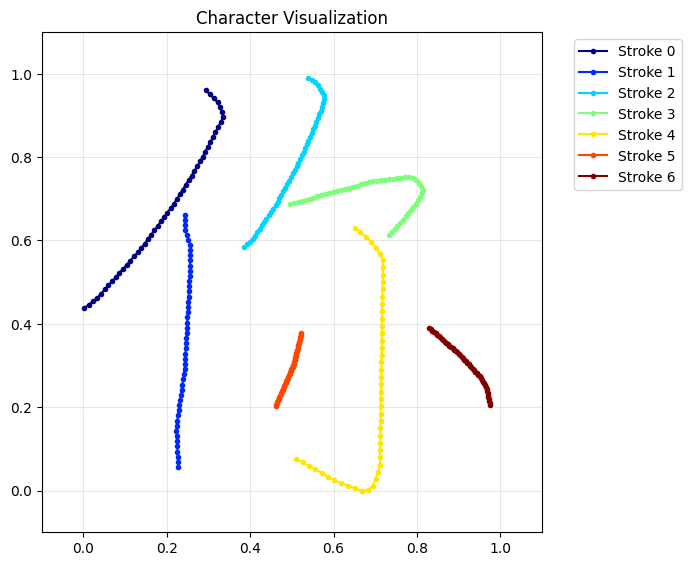

In [73]:


#This needs to work
'''
These parameters specify the liklihood / distribution of these types of errors

missing radical: the prob of a given radical being removed
component_size: std of percent increase / decrease in size
component_spacing: std of x / y offset with mean 0
stroke_length - std of of elongation with mean 0 
stroke_angle - std of stroke angle mistake
stroke_order - probability of an order mistake within each radical
stroke_direction - probability of a stroke being the wrong direction
motor_noise - level indicating motor noise 

Assumptions here: 

continuous perterbations are gaussian
radical, stroke_order probability mistakes are the same across sets of strokes and across radicals 
stroke_direction mistake probability is the same for all strokes
probability of a given radical being forgotten is the same for all radicals
assume that these values don't change for each stroke. 

Other errors aren't important, including extra strokes / radicals

Right now, I plan on using the same values for each character. In the future we could learn 
these values for each character and subcomponent from data. But, this gives a rough approximation. 

'''

def perturb_character(char, strokes, char_db,
                      p_missing_radical=0.0,
                      p_missing_stroke=0.0,
                      component_size_std=0.0,
                      component_spacing_std=0.0,
                      p_stroke_order=0.0,
                      reverse_prob=0.0):
    result = list(strokes)

    if p_missing_radical > 0:
        result = remove_radicals_stochastic(char, result, p_missing_radical, char_db)
        if not result:
            return result

    if p_missing_stroke > 0:
        result = remove_strokes_stochastic(result, p_missing_stroke)
        if not result:
            return result

    if component_size_std > 0:
        result = scale_radicals_stochastic(char, result, component_size_std, char_db)

    if component_spacing_std > 0:
        result = shift_radicals_stochastic(char, result, component_spacing_std, char_db)

    if p_stroke_order > 0:
        result = shuffle_strokes_stochastic(char, result, p_stroke_order, char_db)

    if reverse_prob > 0:
        result = reverse_strokes_stochastic(result, reverse_prob)

    return result

result = perturb_character(
    char='你',
    strokes=normalized_reference_data['你'],
    char_db=char_dict,
    p_missing_radical=0.06,
    p_missing_stroke=0.02,
    component_size_std=0.06,
    component_spacing_std=0.03,
    p_stroke_order=0.04,
    reverse_prob = 0.05
)
plot_character(result)

In [17]:
characters = [
    '的', '一', '是', '不', '了', '人', '我', '在', '有', '他',
    '这', '为', '之', '大', '来', '以', '个', '中', '上', '们',
    '到', '说', '国', '和', '地', '也', '子', '时', '道', '出',
    '而', '要', '于', '就', '下', '得', '可', '你', '年', '生',
    '自', '会', '那', '后', '能', '对', '着', '事', '其', '里',
    '所', '去', '行', '过', '家', '十', '用', '发', '天', '如',
    '然', '作', '方', '成', '者', '多', '日', '都', '三', '小',
    '军', '二', '无', '同', '么', '经', '法', '当', '起', '与',
    '好', '看', '学', '进', '种', '将', '还', '分', '此', '心',
    '前', '面', '又', '定', '见', '只', '主', '没', '公', '从'
]



#this actually isn't used on the CASIA data, only used for testing.
#input is a list of chars, output is the same list of chars plus n distorted copies of each one.
def create_synthetic_dataset(characters, n):
    dataset = {}
    for char in characters: 
        per_char_data = []
        per_char_data.append(char)
        
        for i in range(n):
            result = perturb_character(
                char='你',
                strokes=normalized_reference_data['你'],
                char_db=char_dict,
                p_missing_radical=0.06,
                p_missing_stroke=0.02,
                component_size_std=0.06,
                component_spacing_std=0.03,
                p_stroke_order=0.04,
                reverse_prob = 0.05
            )
            per_char_data.append(result)
        dataset[char] = per_char_data
    return dataset
    

dataset = create_synthetic_dataset(characters, 100)

print(len(dataset['的']))
    

    

101


In [ ]:
print(len(dataset['的']))

/var/folders/5d/54bqcs7s7_s78b1h3n5x3jwm0000gn/T/ipykernel_44295/1869966697.py:29: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/keanehaesle/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


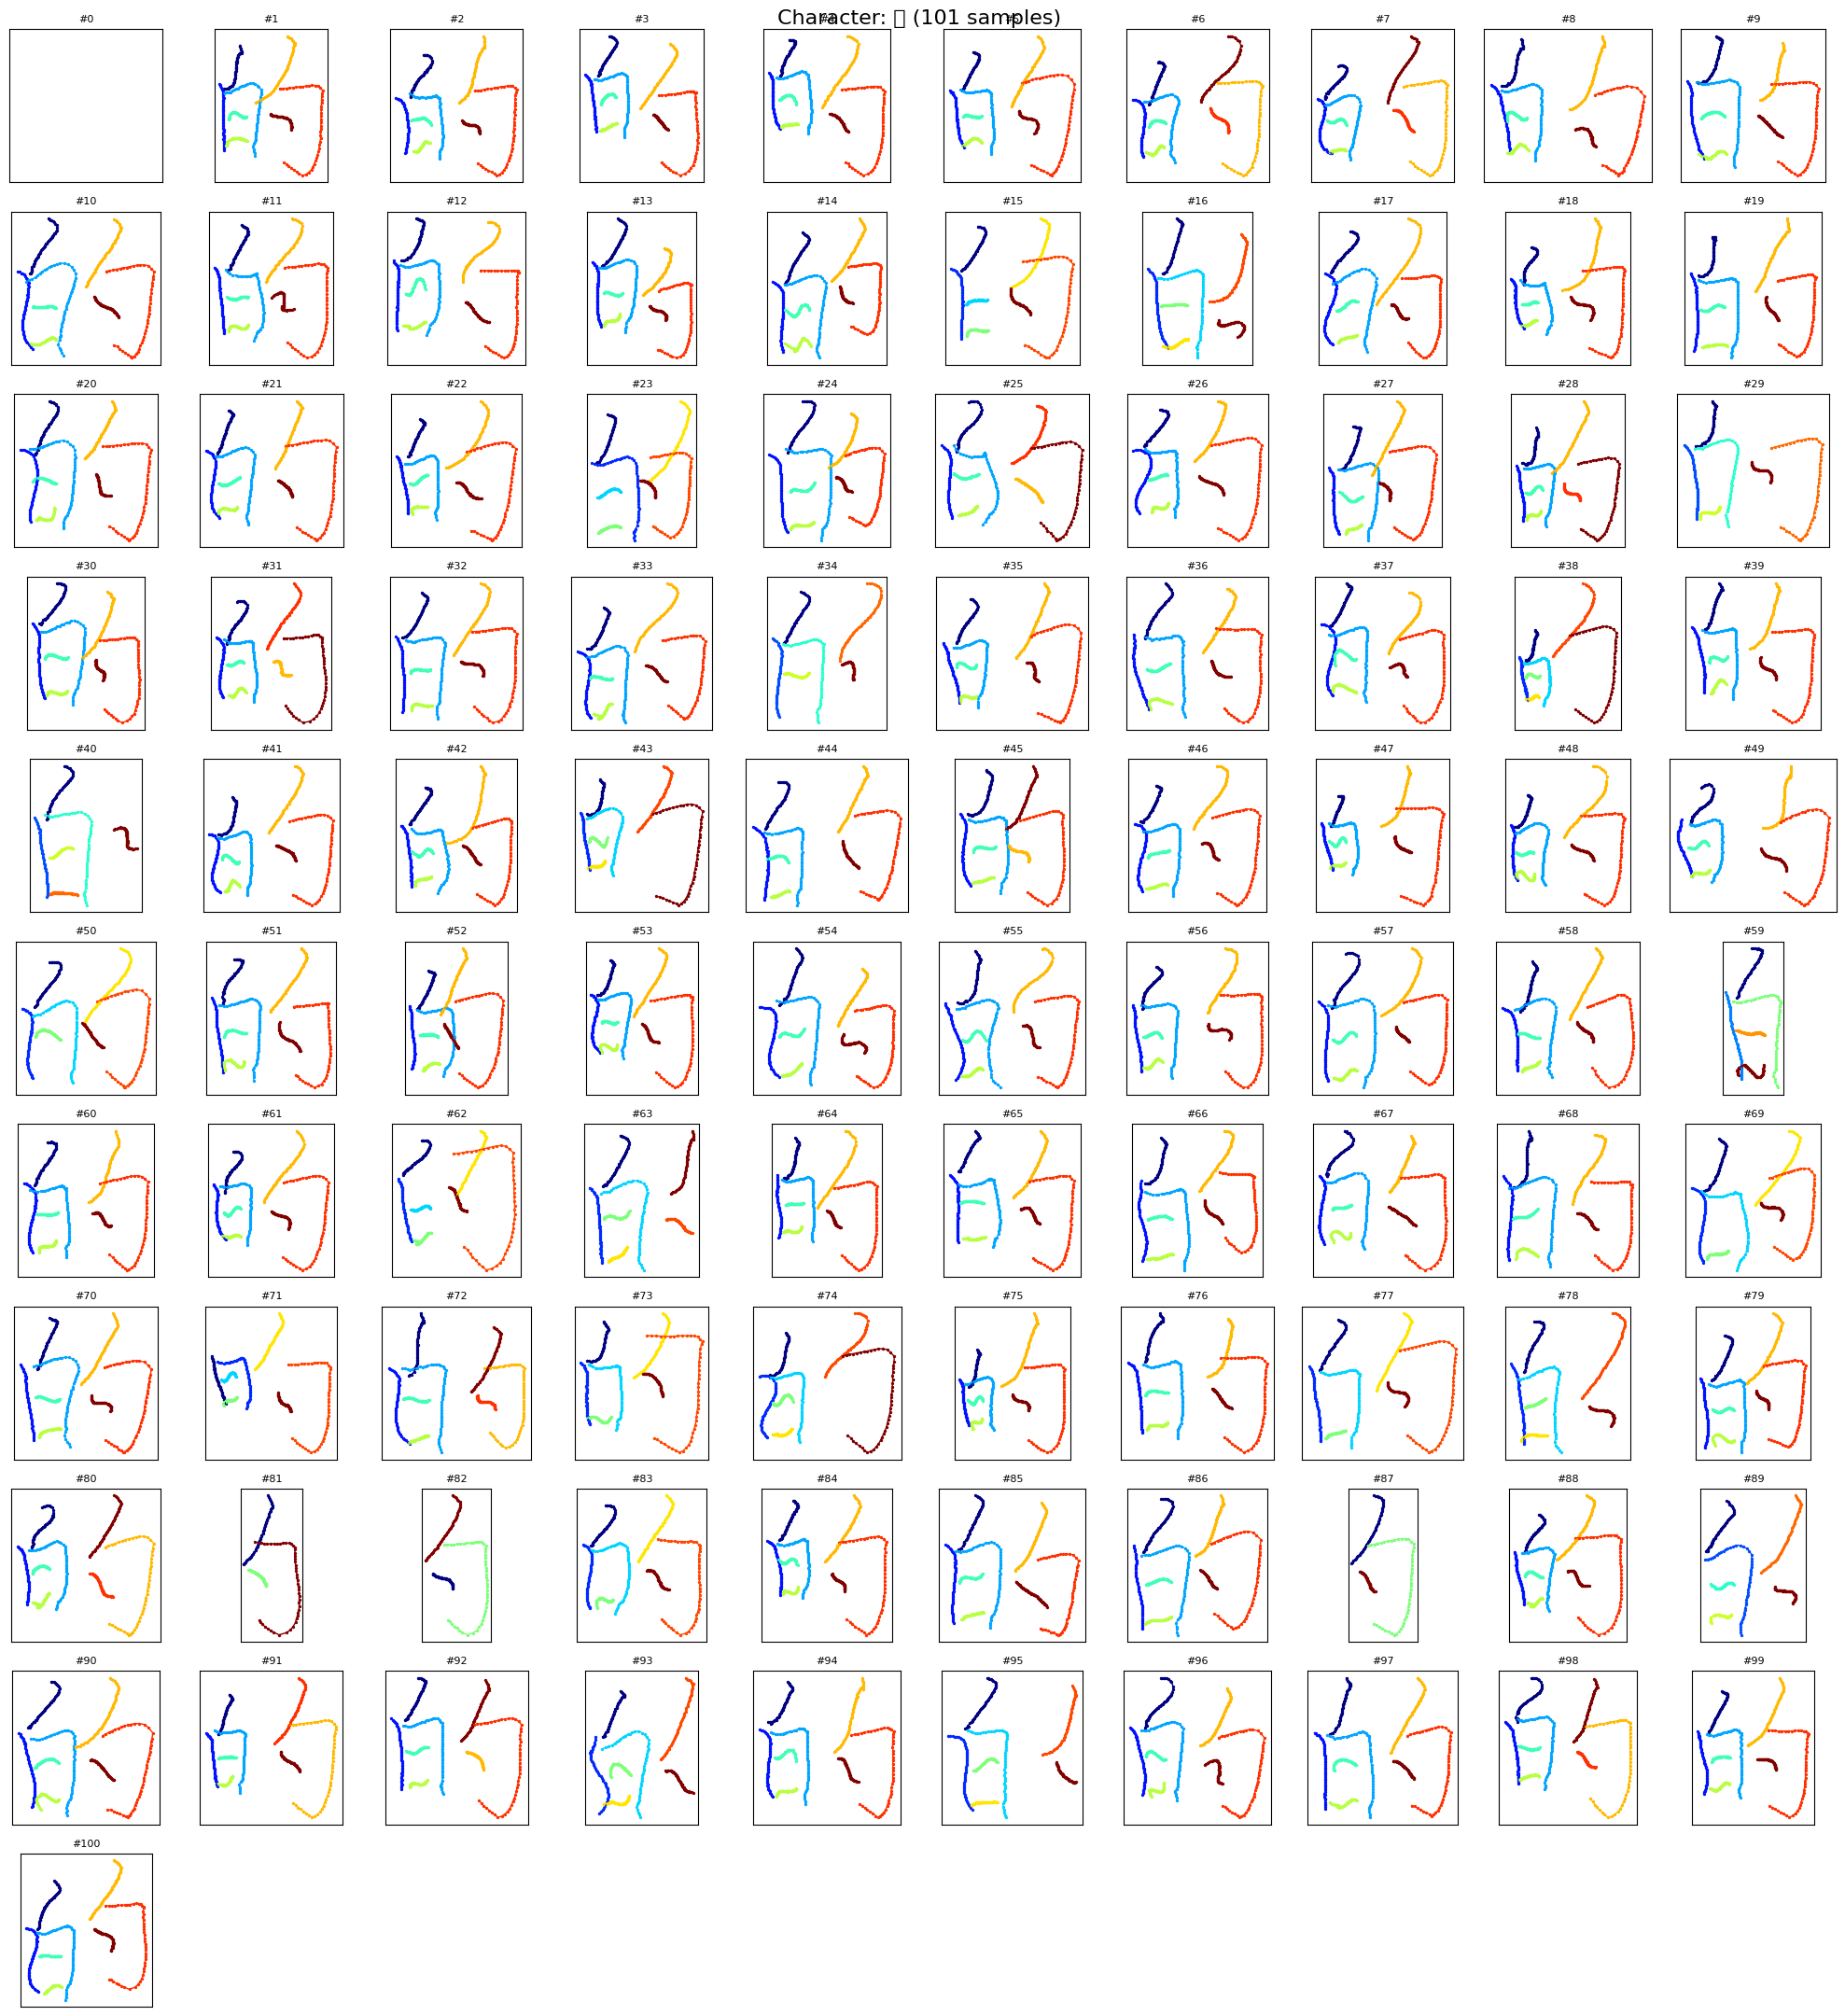

In [23]:
import matplotlib.pyplot as plt

def visualize_char_samples(char, samples, cols=10):
    n = len(samples)
    rows = int(np.ceil(n / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()
    
    for i, strokes in enumerate(samples):
        ax = axes[i]
        colors = plt.cm.jet(np.linspace(0, 1, len(strokes)))
        for stroke, color in zip(strokes, colors):
            stroke = np.array(stroke)
            if stroke.ndim < 2 or len(stroke) == 0:
                continue
            ax.plot(stroke[:, 0], stroke[:, 1], color=color, linewidth=1)
            ax.scatter(stroke[:, 0], stroke[:, 1], color=color, s=2)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')
        ax.set_title(f'#{i}', fontsize=8)

    # hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'Character: {char} ({n} samples)', fontsize=16)
    plt.tight_layout()
    plt.show()

visualize_char_samples('的', dataset['的'])

In [ ]:
def augment_stroke_data(char, p_remove=0.05, p_swap=0.1, p_reverse=0.05):
    result = list(char)

    # remove strokes and cascade to neighbours. Writer is more likely to forget adjacent strokes
    i = 0
    removed = set()
    while i < len(result):
        if random.random() < p_remove:
            removed.add(i)
            if i - 1 >= 0 and i - 1 not in removed:
                if random.random() < p_remove:
                    removed.add(i - 1)
            if i + 1 < len(result) and i + 1 not in removed:
                if random.random() < p_remove:
                    removed.add(i + 1)
        i += 1

    result = [s for i, s in enumerate(result) if i not in removed]
    if not result:
        result = [random.choice(strokes)]

    # swap adjacent strokes
    for i in range(len(result) - 1):
        if random.random() < p_swap:
            result[i], result[i+1] = result[i+1], result[i]

    # reverse individual stroke direction
    result = [s[::-1] if random.random() < p_reverse else s for s in result]

    return result